In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

#**1. Data Preprocessing (Review & Extension)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

marketing_campaign_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/marketing_campaign.csv', sep = '\t')
marketing_campaign_df.head()

Mounted at /content/drive


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
print("Missing values per column:")
print(marketing_campaign_df.isnull().sum()[marketing_campaign_df.isnull().sum() > 0])

Missing values per column:
Income    24
dtype: int64


##**Handling Missing Values by Median**
We use the median instead of the mean because **Income** distributions often have extreme outliers (like millionaires) that can artificially skew the average. The median gives us a much more robust (middle) value.

In [ ]:
income_median = marketing_campaign_df['Income'].median()
print(f"\nCalculated Median Income: {income_median}")

marketing_campaign_df['Income'] = marketing_campaign_df['Income'].fillna(income_median)

print(f"Missing values in Income after imputation: {marketing_campaign_df['Income'].isnull().sum()}")


Calculated Median Income: 51381.5
Missing values in Income after imputation: 0


In [ ]:
marketing_campaign_df['Age'] = 2026 - marketing_campaign_df['Year_Birth']

spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
marketing_campaign_df['TotalSpending'] = marketing_campaign_df[spending_cols].sum(axis = 1)

marketing_campaign_df['TotalChildren'] = marketing_campaign_df['Kidhome'] + marketing_campaign_df['Teenhome']

valide_age_condition = (marketing_campaign_df['Age'] >= 18) & (marketing_campaign_df['Age'] <= 100)
valide_income_condition = (marketing_campaign_df['Income'] > 0)

filtered_marketing_campaign_df = marketing_campaign_df[valide_age_condition & valide_income_condition].copy()
filtered_marketing_campaign_df.shape

(2237, 32)

In [ ]:
filtered_marketing_campaign_df['Education'].value_counts()

,count
Education,
Graduation,1127
PhD,485
Master,370
2n Cycle,201
Basic,54


In [ ]:
filtered_marketing_campaign_df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,864
Together,579
Single,479
Divorced,231
Widow,77
Alone,3
Absurd,2
YOLO,2


In [ ]:
education_mapping = {"Basic": 0, "Graduation": 1, "Master": 2, "PhD": 3, "2n Cycle": 2} # Mapping 2n Cycle with Master as it's equivalent
filtered_marketing_campaign_df['Education'] = filtered_marketing_campaign_df['Education'].map(education_mapping)

top_4_marital = filtered_marketing_campaign_df['Marital_Status'].value_counts().index[:4]
filtered_marketing_campaign_df['Marital_Status'] = filtered_marketing_campaign_df['Marital_Status'].apply(lambda status: status if status in top_4_marital else 'Other')

filtered_marketing_campaign_df = pd.get_dummies(filtered_marketing_campaign_df, columns = ['Marital_Status'], drop_first = False)

print("Encoding complete! Current columns in the dataframe:")
print([col for col in filtered_marketing_campaign_df.columns if 'Marital_Status' in col or col == 'Education'])

Encoding complete! Current columns in the dataframe:
['Education', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Other', 'Marital_Status_Single', 'Marital_Status_Together']


#**2. Supervised Learning - Regression**

In [ ]:
feature_cols = ['Income', 'Age', 'Education', 'TotalChildren',
                'Marital_Status_Divorced', 'Marital_Status_Married',
                'Marital_Status_Other', 'Marital_Status_Single', 'Marital_Status_Together']

feature = filtered_marketing_campaign_df[feature_cols]
target = filtered_marketing_campaign_df['TotalSpending']

print(f"Features shape: {feature.shape}")
print(f"Target shape: {target.shape}")

Features shape: (2237, 9)
Target shape: (2237,)


In [ ]:
feature_train, feature_test, target_train, target_test = train_test_split(feature, target, test_size = 0.2, random_state = 42)
print(f"Training features: {feature_train.shape}, Testing features: {feature_test.shape}")

Training features: (1789, 9), Testing features: (448, 9)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

pipelines = {
    "Linear Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha = 1.0))
    ]),
    "Decision Tree (max_depth=5)": Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', DecisionTreeRegressor(max_depth = 5, random_state = 42))
    ])
}

regression_results = {}

for name, pipeline in pipelines.items():
    # Fit the entire pipeline on the raw training data safely
    pipeline.fit(feature_train, target_train)

    # Predict using testing data without data leakage
    preds = pipeline.predict(feature_test)

    # Calculate required metrics
    mse = mean_squared_error(target_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(target_test, preds)

    # Store metrics
    regression_results[name] = {"MSE": mse, "RMSE": rmse, "R2 Score": r2}

regression_comparison_df = pd.DataFrame(regression_results).T
regression_comparison_df

,MSE,RMSE,R2 Score
Linear Regression,130688.614584,361.508803,0.655969
Ridge Regression,130734.990765,361.572940,0.655847
Decision Tree (max_depth=5),81208.763457,284.971513,0.786222


##**Why Ridge?**
Standard Linear Regression risks overfitting and coefficient instability when features display high correlation. Ridge resolves this by introducing an $L_2$ penalty to the objective function, constraining parameter weights to enhance performance stability on unseen datasets

#**3. Supervised Learning - Classification**

Class Distribution for 'Response': 
Response
0    1903
1     334
Name: count, dtype: int64

Percentage Distribution: 
Response
0    85.069289
1    14.930711
Name: proportion, dtype: float64


/tmp/ipykernel_2434/2272914526.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Response', data = filtered_marketing_campaign_df, palette = 'Set2')


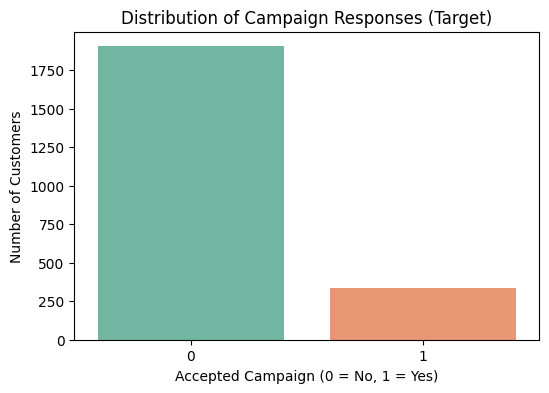

In [ ]:
print("Class Distribution for 'Response': ")
print(filtered_marketing_campaign_df['Response'].value_counts())

print("\nPercentage Distribution: ")
print(filtered_marketing_campaign_df['Response'].value_counts(normalize = True) * 100)

plt.figure(figsize = (6, 4))
sns.countplot(x = 'Response', data = filtered_marketing_campaign_df, palette = 'Set2')
plt.title('Distribution of Campaign Responses (Target)')
plt.xlabel('Accepted Campaign (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

target_classification = filtered_marketing_campaign_df['Response']

feature_train_classification, feature_test_classification, target_train_classification, target_test_classification = train_test_split(feature, target_classification, test_size = 0.2, random_state = 42)

# Pass class_weight='balanced' to Logistic Regression to combat the 85/15 split
classification_models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(class_weight = 'balanced', random_state = 42))
    ]),
    "K-Nearest Neighbors (k = 5)": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors = 5))
    ]),
    "Random Forest": Pipeline([
        ('classifier', RandomForestClassifier(n_estimators = 100, random_state = 42))
    ])
}


 TRAINING MODEL: Logistic Regression 
              precision    recall  f1-score   support

           0       0.89      0.62      0.74       376
           1       0.24      0.61      0.34        72

    accuracy                           0.62       448
   macro avg       0.57      0.62      0.54       448
weighted avg       0.79      0.62      0.67       448



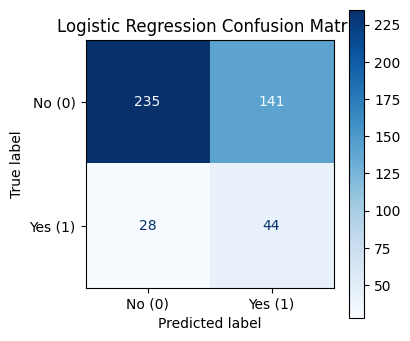


 TRAINING MODEL: K-Nearest Neighbors (k = 5) 
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       376
           1       0.61      0.19      0.29        72

    accuracy                           0.85       448
   macro avg       0.74      0.59      0.61       448
weighted avg       0.82      0.85      0.82       448



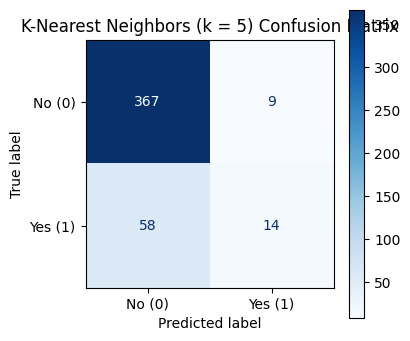


 TRAINING MODEL: Random Forest 
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       376
           1       0.53      0.25      0.34        72

    accuracy                           0.84       448
   macro avg       0.70      0.60      0.63       448
weighted avg       0.81      0.84      0.82       448



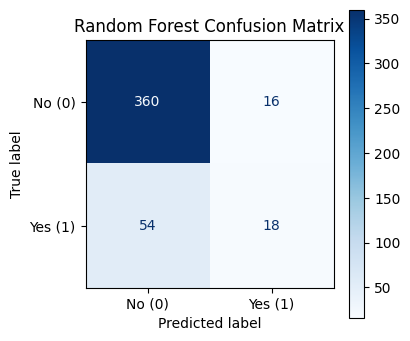

In [ ]:
for name, pipeline in classification_models.items():
    print("\n" + "="*50)
    print(f" TRAINING MODEL: {name} ")
    print("="*50)

    pipeline.fit(feature_train_classification, target_train_classification)

    preds_classification = pipeline.predict(feature_test_classification)

    print(classification_report(target_test_classification, preds_classification))

    cm = confusion_matrix(target_test_classification, preds_classification)
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['No (0)', 'Yes (1)'])

    fig, ax = plt.subplots(figsize = (4, 4))
    disp.plot(ax = ax, cmap = 'Blues', values_format = 'd')
    plt.title(f'{name} Confusion Matrix')
    plt.grid(False)
    plt.show()

##**Why ReLU and Sigmoid?**

* **ReLU (Rectified Linear Unit) for Hidden Layers:** ReLU, defined mathematically as $f(x) = \max(0, x)$, is used within the hidden layers of Deep Neural Networks. It outputs the value directly if it is positive, and outputs zero otherwise. This simple thresholding allows networks to learn complex non-linear relationships efficiently while avoiding the "vanishing gradient problem," keeping training fast and stable.

* **Sigmoid for the Output Layer:** Sigmoid, defined as $S(x) = \frac{1}{1 + e^{-x}}$, takes any real number and compresses it into a strict value between 0 and 1. This mathematical compression maps outputs directly to probabilities, making it the required activation function for binary classification problems (such as determining whether a customer has a 0% or 100% probability of accepting a marketing campaign).

#**Section 4: Unsupervised Learning - Clustering**

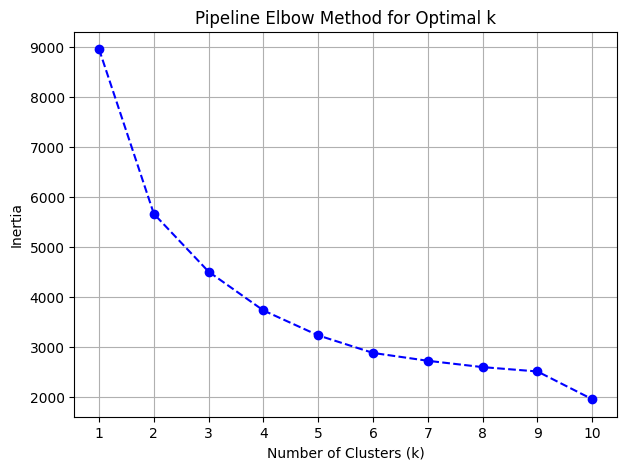

In [ ]:
from sklearn.cluster import KMeans

cluster_features = ['TotalSpending', 'Income', 'Age', 'TotalChildren']
feature_cluster = filtered_marketing_campaign_df[cluster_features]

inertia_pipeline = []
k_range = range(1, 11)

for k in k_range:
    cluster_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters = k, random_state = 42, n_init = 'auto'))
    ])

    cluster_pipe.fit(feature_cluster)

    # Extract the inertia from the kmeans step
    current_inertia = cluster_pipe.named_steps['kmeans'].inertia_
    inertia_pipeline.append(current_inertia)

# Plot the Elbow Curve
plt.figure(figsize = (7, 5))
plt.plot(k_range, inertia_pipeline, marker='o', linestyle='--', color='b')
plt.title('Pipeline Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [ ]:
final_cluster_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters = 3, random_state = 42, n_init = 'auto'))
])

filtered_marketing_campaign_df['Cluster'] = final_cluster_pipeline.fit_predict(feature_cluster)

print("Customer count per cluster:")
print(filtered_marketing_campaign_df['Cluster'].value_counts())

Customer count per cluster:
Cluster
2    772
0    738
1    727
Name: count, dtype: int64


##**Why k = 3?**

**Optimal Balance:** The curve drops steeply from $k=1$ to $k=3$, indicating that adding these clusters dramatically increases grouping tightness. Right after $k=3$, the line levels out and becomes shallow, meaning any additional clusters offer diminishing returns while overcomplicating the segmentation model.

In [ ]:
cluster_profiles = filtered_marketing_campaign_df.groupby('Cluster')[['Income', 'TotalSpending', 'Age', 'TotalChildren']].mean()

print("=== FINAL CUSTOMER SEGMENTATION PROFILES ===")
display(cluster_profiles)

=== FINAL CUSTOMER SEGMENTATION PROFILES ===


,Income,TotalSpending,Age,TotalChildren
Cluster,,,,
0,33235.539295,161.471545,48.714092,0.853659
1,47763.638239,314.640990,64.181568,1.660248
2,74586.422280,1304.582902,58.443005,0.375648


**Cluster 2 (The Affluent Power Spenders):** High income, massive spending capability, mature age bracket, and minimal children at home.

**Cluster 1 (The Mature Budget Families):** Middle-aged profile, lower income margins, largest household count of children, and highly restricted spending habits.

**Cluster 0 (The Younger Starter Segment):** Youngest average consumer demographic, lowest starting career revenue, and low retail spending metric

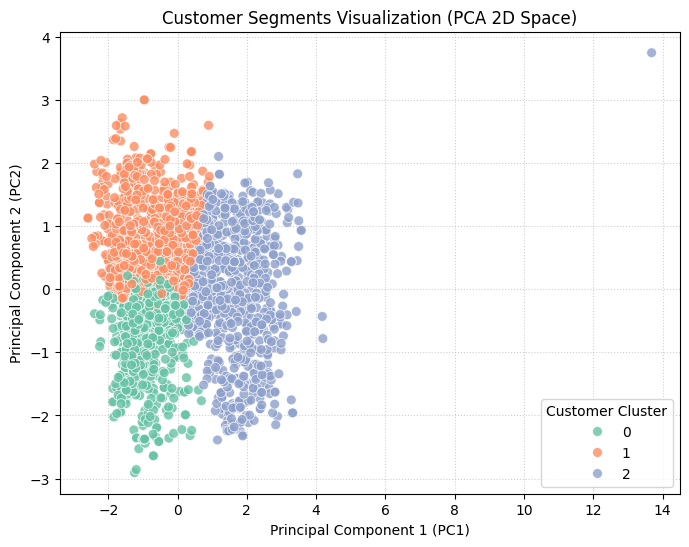

In [ ]:
from sklearn.decomposition import PCA

# 1. Project our 4-dimensional scaled data down to 2 components
pca = PCA(n_components = 2, random_state = 42)
feature_pca = pca.fit_transform(StandardScaler().fit_transform(feature_cluster))

# 2. Put the 2 components into a temporary dataframe for easy plotting
pca_df = pd.DataFrame(data = feature_pca, columns = ['PC1', 'PC2'])
pca_df['Cluster'] = filtered_marketing_campaign_df['Cluster'].values

# 3. Plot the scatter map using our elegant Set2 palette
plt.figure(figsize = (8, 6))
sns.scatterplot(x = 'PC1', y = 'PC2', hue = 'Cluster', data = pca_df, palette = 'Set2', alpha = 0.8, edgecolor = 'w', s = 50)
plt.title('Customer Segments Visualization (PCA 2D Space)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Customer Cluster')
plt.grid(True, linestyle = ':', alpha = 0.6)
plt.show()